<a href="https://colab.research.google.com/github/zunairanaseer0375-cyber/CodeAlpha_CreditScoringModel/blob/main/CodeAlpha_HandwrittenCharacterRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Task 3: Handwritten Character Recognition
# Step 1: Environment Setup

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.1.3


In [ ]:
# Step 2: Load MNIST Dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [ ]:
# Step 3: Basic Dataset Analysis

print("Number of training samples:", len(x_train))
print("Number of testing samples:", len(x_test))
print("Image dimensions:", x_train[0].shape)
print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))

Number of training samples: 60000
Number of testing samples: 10000
Image dimensions: (28, 28)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


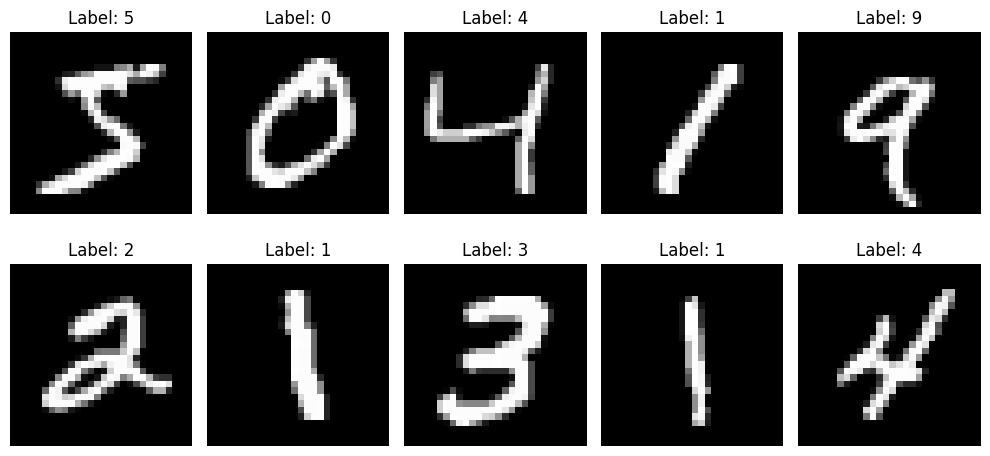

In [ ]:
# Step 4: Visualize Sample Images

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Image Preprocessing

# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension for CNN: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Preprocessed training shape:", x_train.shape)
print("Preprocessed testing shape:", x_test.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

Preprocessed training shape: (60000, 28, 28, 1)
Preprocessed testing shape: (10000, 28, 28, 1)
Pixel value range: 0.0 to 1.0


In [ ]:
# Step 6: Create Validation Set

from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)

Training set: (54000, 28, 28, 1)
Validation set: (6000, 28, 28, 1)
Test set: (10000, 28, 28, 1)


In [ ]:
# Step 7: Build CNN Model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Step 8: Compile CNN Model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# Step 9: Configure Training Callbacks

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Training callbacks configured successfully.")

Training callbacks configured successfully.


In [ ]:
# Step 10: Train CNN Model

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 183ms/step - accuracy: 0.9471 - loss: 0.1785 - val_accuracy: 0.5853 - val_loss: 1.8734 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 187ms/step - accuracy: 0.9813 - loss: 0.0628 - val_accuracy: 0.9858 - val_loss: 0.0489 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 180ms/step - accuracy: 0.9864 - loss: 0.0446 - val_accuracy: 0.9873 - val_loss: 0.0530 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 182ms/step - accuracy: 0.9898 - loss: 0.0331 - val_accuracy: 0.9880 - val_loss: 0.0468 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 75s 178ms/step - accuracy: 0.9907 - loss: 0.0305 - val_accuracy: 0.9887 - val_loss: 0.0476 - learning_rate: 0.0010
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 182ms/step - accuracy: 0.9917 - loss: 0.0257 - val_accuracy: 0.9885 - val_loss: 0.0420 - learning_rate: 0.0010
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 188ms/step - accuracy: 0.9

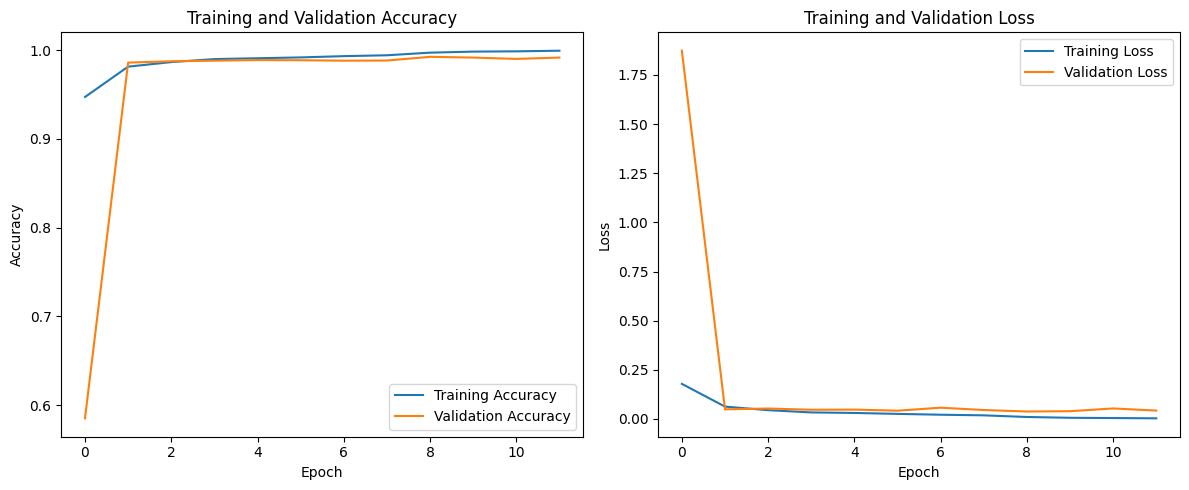

In [13]:
# Step 11: Visualize Training Performance

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Step 12: Test Set Evaluation

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9931 - loss: 0.0312
Test Loss: 0.031200245022773743
Test Accuracy: 0.9930999875068665


In [16]:
# Step 13: Classification Report

from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(x_test), axis=1)

print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



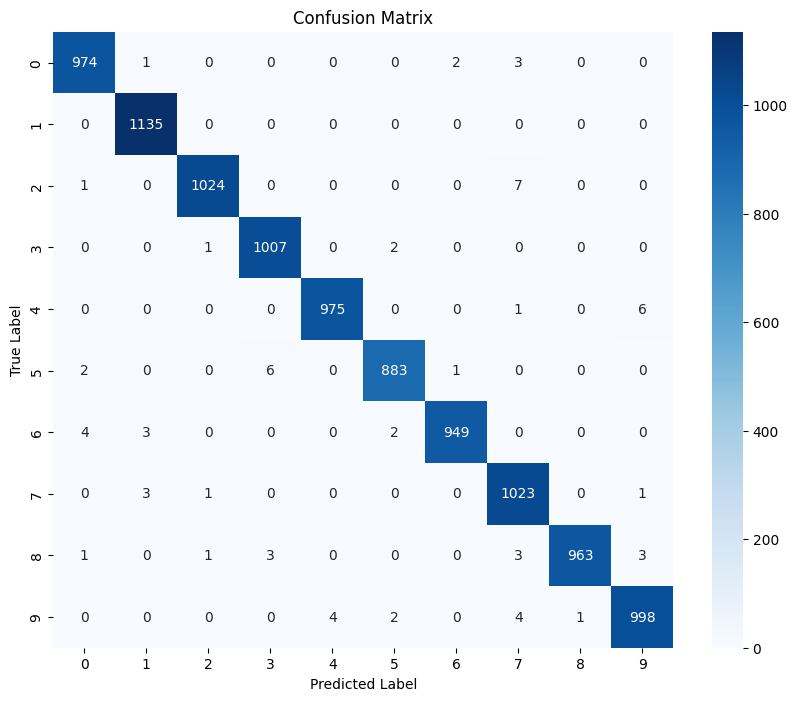

In [17]:
# Step 14: Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


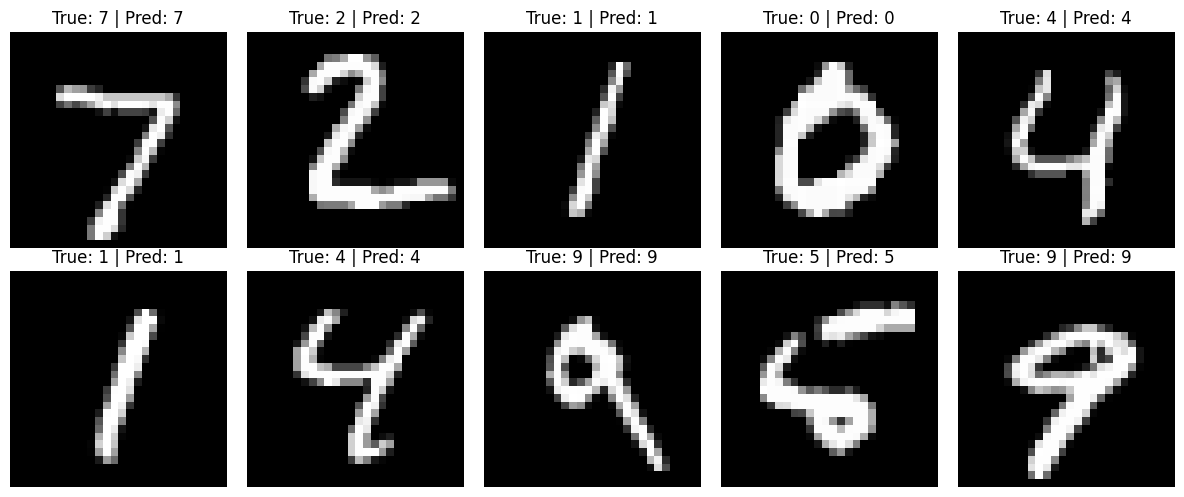

In [18]:
# Step 15: Visualize Sample Predictions

predictions = model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"True: {y_test[i]} | Pred: {predicted_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Step 16: Save Trained Model

model.save("handwritten_character_recognition_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [20]:
# Step 17: Load Saved Model

loaded_model = tf.keras.models.load_model(
    "handwritten_character_recognition_model.keras"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [21]:
# Step 18: Verify Loaded Model

loaded_loss, loaded_accuracy = loaded_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9931 - loss: 0.0312
Loaded Model Test Loss: 0.031200245022773743
Loaded Model Test Accuracy: 0.9930999875068665


In [22]:
# Step 19: Final Model Summary

print("===== Final Model Results =====")
print("Model: CNN")
print("Dataset: MNIST")
print("Number of Classes: 10")
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))
print("Test Loss: {:.4f}".format(test_loss))
print("Model File: handwritten_character_recognition_model.keras")

===== Final Model Results =====
Model: CNN
Dataset: MNIST
Number of Classes: 10
Test Accuracy: 99.31%
Test Loss: 0.0312
Model File: handwritten_character_recognition_model.keras


In [23]:
# Step 20: Task Completion Check

print("===== Task 3 Completed Successfully =====")
print("Handwritten Character Recognition using CNN")
print("Final Test Accuracy: {:.2f}%".format(test_accuracy * 100))
print("Model saved and verified successfully.")
print("All required evaluation steps completed.")

===== Task 3 Completed Successfully =====
Handwritten Character Recognition using CNN
Final Test Accuracy: 99.31%
Model saved and verified successfully.
All required evaluation steps completed.
